# baselina model for batch monitoring example

In [34]:
!pip install --upgrade evidently




[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [38]:

import sys
!{sys.executable} -m pip install --upgrade evidently


In [1]:
import requests
import datetime
import pandas as pd
import matplotlib
from joblib import load, dump
from tqdm import tqdm

from evidently import ColumnMapping
from evidently.report import Report
from evidently.metrics import ColumnDriftMetric, DatasetDriftMetric, DatasetMissingValuesMetric


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

ImportError: cannot import name 'ColumnMapping' from 'evidently' (/home/vagrant/anaconda3/envs/py11/lib/python3.11/site-packages/evidently/__init__.py)

In [3]:
files = [('green_tripdata_2022-02.parquet', './data'), ('green_tripdata_2022-01.parquet', './data')]

print("Download files:")
for file, path in files:
    url=f"https://d37ci6vzurychx.cloudfront.net/trip-data/{file}"
    resp=requests.get(url, stream=True)
    save_path=f"{path}/{file}"
    with open(save_path, "wb") as handle:
        for data in tqdm(resp.iter_content(),
                        desc=f"{file}",
                        postfix=f"save to {save_path}",
                        total=int(resp.headers["Content-Length"])):
            handle.write(data)

Download files:


green_tripdata_2022-01.parquet: 100%|██████████| 1254291/1254291 [00:05<00:00, 224436.90it/s, save to ./data/green_tripdata_2022-01.parquet]


In [4]:
jan_data = pd.read_parquet('data/green_tripdata_2022-01.parquet')

In [5]:
jan_data.describe

<bound method NDFrame.describe of        VendorID lpep_pickup_datetime  ... trip_type congestion_surcharge
0             2  2022-01-01 00:14:21  ...       1.0                 0.00
1             1  2022-01-01 00:20:55  ...       1.0                 0.00
2             1  2022-01-01 00:57:02  ...       1.0                 2.75
3             2  2022-01-01 00:07:42  ...       1.0                 0.00
4             2  2022-01-01 00:07:50  ...       1.0                 2.75
...         ...                  ...  ...       ...                  ...
62490         2  2022-01-31 23:25:00  ...       NaN                  NaN
62491         2  2022-01-31 23:52:00  ...       NaN                  NaN
62492         2  2022-01-31 23:17:00  ...       NaN                  NaN
62493         2  2022-01-31 23:45:00  ...       NaN                  NaN
62494         2  2022-01-31 23:52:00  ...       NaN                  NaN

[62495 rows x 20 columns]>

In [6]:
jan_data.shape

(62495, 20)

In [7]:
# create target
jan_data["duration_min"] = jan_data.lpep_dropoff_datetime - jan_data.lpep_pickup_datetime
jan_data.duration_min = jan_data.duration_min.apply(lambda td: float(td.total_seconds()) / 60)

In [8]:
# filter out outliers
jan_data = jan_data[
    (jan_data.duration_min >= 0) & (jan_data.duration_min <= 60)
]
jan_data = jan_data[
    (jan_data.passenger_count > 0) & (jan_data.passenger_count <= 8)
]

In [11]:
import sys
!{sys.executable} -m pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 27.0 MB/s eta 0:00:0031m39.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 14.7 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]


<Axes: >

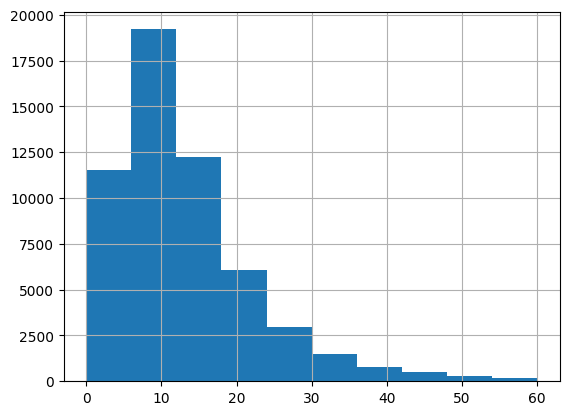

In [12]:
jan_data.duration_min.hist()

In [13]:
# data labeling
target = "duration_min"
num_features = ["passenger_count", "trip_distance", "fare_amount", "total_amount"]
cat_features = ["PULocationID", "DOLocationID"]

In [14]:
jan_data.shape

(55211, 21)

In [15]:
train_data = jan_data[:30000]
val_data = jan_data[30000:]

In [16]:
model = LinearRegression()

In [17]:
model.fit(train_data[num_features + cat_features], train_data[target])

LinearRegression()

In [18]:
train_preds = model.predict(train_data[num_features + cat_features])
train_data['prediction'] = train_preds

/tmp/ipykernel_5580/3810346118.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['prediction'] = train_preds


In [21]:
val_preds = model.predict(val_data[num_features + cat_features])
val_data['prediction'] = val_preds

/tmp/ipykernel_5580/3727490221.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_data['prediction'] = val_preds


In [22]:
print(mean_absolute_error(train_data.duration_min, train_data.prediction))
print(mean_absolute_error(val_data.duration_min, val_data.prediction))

3.804665373785062
4.142064073688447


# Dump model and reference data

In [23]:
with open('models/lin_reg.bin', 'wb') as f_out:
    dump(model, f_out)

In [24]:
val_data.to_parquet('data/reference.parquet')

# Evidently Report

In [26]:
column_mapping = ColumnMapping(
    target=None,
    prediction='prediction',
    numerical_features=num_features,
    categorical_features=cat_features
)

NameError: name 'ColumnMapping' is not defined